### Amazon Fruits Dataset

## Task 1: Data Understanding and Visualization

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import zipfile
import os

zip_file_path = '/content/FruitinAmazon.zip'
extraction_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped to '{extraction_path}' successfully.")
print(f"Contents of the extraction directory: {os.listdir(extraction_path)}")

'/content/FruitinAmazon.zip' unzipped to './' successfully.
Contents of the extraction directory: ['.config', 'FruitinAmazon.zip', 'drive', 'FruitinAmazon', 'sample_data']


In [5]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.metrics import classification_report

train_dir = '/content/FruitinAmazon/train'
test_dir  = '/content/FruitinAmazon/test'

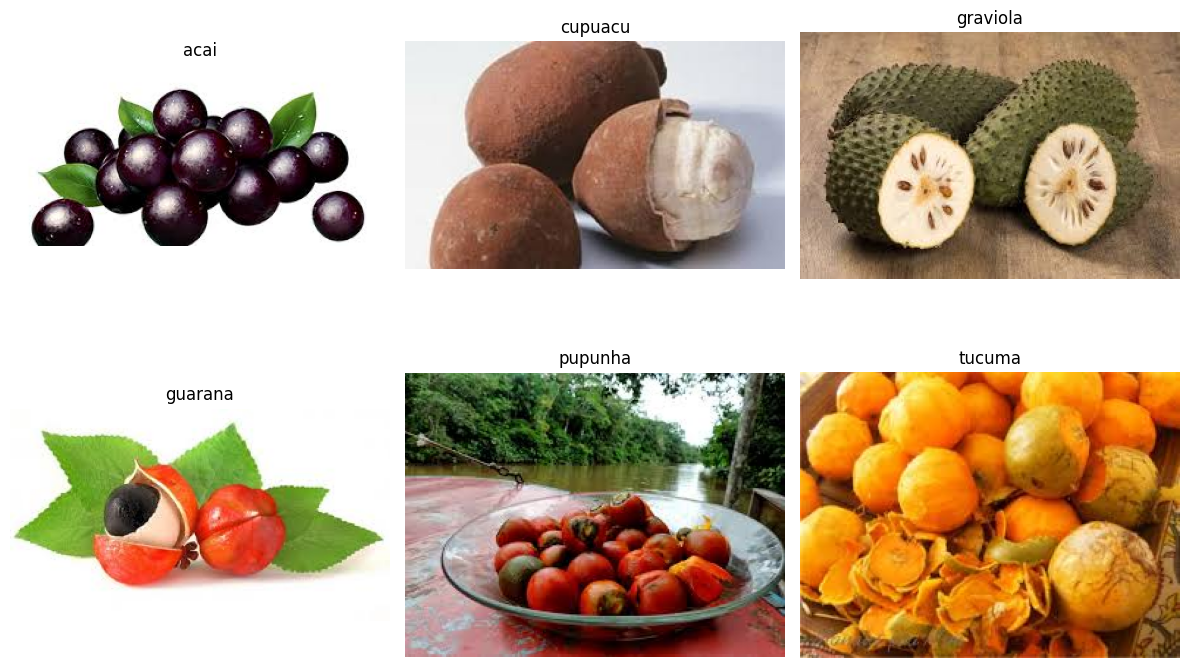

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Observation: Images vary in size, background, and lighting across classes.


In [6]:
# Task 1.1 - Visualise one random image per class in a 2-row grid
class_dirs = sorted(os.listdir(train_dir))
num_classes = len(class_dirs)

cols = (num_classes + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(cols * 4, 8))
axes = axes.flatten()

for i, cls in enumerate(class_dirs):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)
    img_path = os.path.join(cls_path, random.choice(images))  # random sample
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print(f"Classes found: {class_dirs}")
print("Observation: Images vary in size, background, and lighting across classes.")

In [7]:
# Task 1.2 - Check for and remove corrupted images
corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


## Task 2: Loading and Preprocessing Image Data

In [8]:
# Hyperparameters
img_height      = 128
img_width       = 128
batch_size      = 16
validation_split = 0.2

# Normalise pixel values to [0, 1]
rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Test dataset (no split, full folder)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

print(f"Number of classes: {num_classes}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Number of classes: 6


## Task 3: Build the CNN Model

In [9]:
# CNN architecture
model = keras.Sequential([

    # Conv Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    # Conv Block 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    # Flatten and fully connected layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),  # hidden layer 1
    layers.Dense(64,  activation='relu'),  # hidden layer 2

    # Output layer
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Compile and Train the Model

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# Callbacks: save best model and stop early if no improvement
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.2146 - loss: 3.1181
Epoch 1: val_accuracy improved from None to 0.11111, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 475ms/step - accuracy: 0.2083 - loss: 3.0751 - val_accuracy: 0.1111 - val_loss: 2.4821
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.3656 - loss: 1.6374
Epoch 2: val_accuracy improved from 0.11111 to 0.16667, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 567ms/step - accuracy: 0.3333 - loss: 1.7127 - val_accuracy: 0.1667 - val_loss: 2.0448
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.3361 - loss: 1.4843
Epoch 3: val_accuracy improved from 0.16667 to 0.22222, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 328ms/step - accuracy: 0.3889 - loss: 1.4196 - val_accuracy: 0.2222 - val_loss: 1.7365
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.4722 - loss: 1.2289
Epoch 4: val_accuracy improved from 0.22222 to 0.77778, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 336ms/step - accuracy: 0.4861 - loss: 1.2214 - val_accuracy: 0.7778 - val_loss: 1.0541
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.7250 - loss: 0.9290
Epoch 5: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - accuracy: 0.7500 - loss: 0.8912 - val_accuracy: 0.7222 - val_loss: 0.8903
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.8090 - loss: 0.6017
Epoch 6: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step - accuracy: 0.8056 - loss: 0.5923 - val_accuracy: 0.7222 - val_loss: 0.6430
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9677 - loss: 0.3277
Epoch 7: val_accuracy improved from 0.77778 to 0.94444, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step - accuracy: 0.9583 - loss: 0.3522 - val_accuracy: 0.9444 - val_loss: 0.3044
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9712 - loss: 0.1848
Epoch 8: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 279ms/step - accuracy: 0.9861 - loss: 0.1764 - val_accuracy: 0.8333 - val_loss: 0.5369
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 1.0000 - loss: 0.1031
Epoch 9: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 451ms/step - accuracy: 1.0000 - loss: 0.1017 - val_accuracy: 0.8333 - val_loss: 0.2248
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 1.0000 - loss: 0.0482
Epoch 10: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 471ms/step - accuracy: 1.0000 - loss: 0.0481 - val_accuracy: 0.8333 - val_loss: 0.2460
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 1.0000 - loss: 0.


Epoch 13: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 320ms/step - accuracy: 1.0000 - loss: 0.0083 - val_accuracy: 1.0000 - val_loss: 0.0991
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 1.0000 - loss: 0.0060
Epoch 14: val_accuracy did not improve from 1.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 0.8889 - val_loss: 0.1608
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 1.0000 - loss: 0.0026
Epoch 15: val_accuracy did not improve from 1.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 296ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.8333 - val_loss: 0.2512
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 1.0000 - loss: 0.0025
Epoch 16: val_accuracy did not improve from 1.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 484ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.8333 - val_loss: 0.2798
Epoch 17/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 1.0000 - los

## Visualisation: Training & Validation Loss/Accuracy

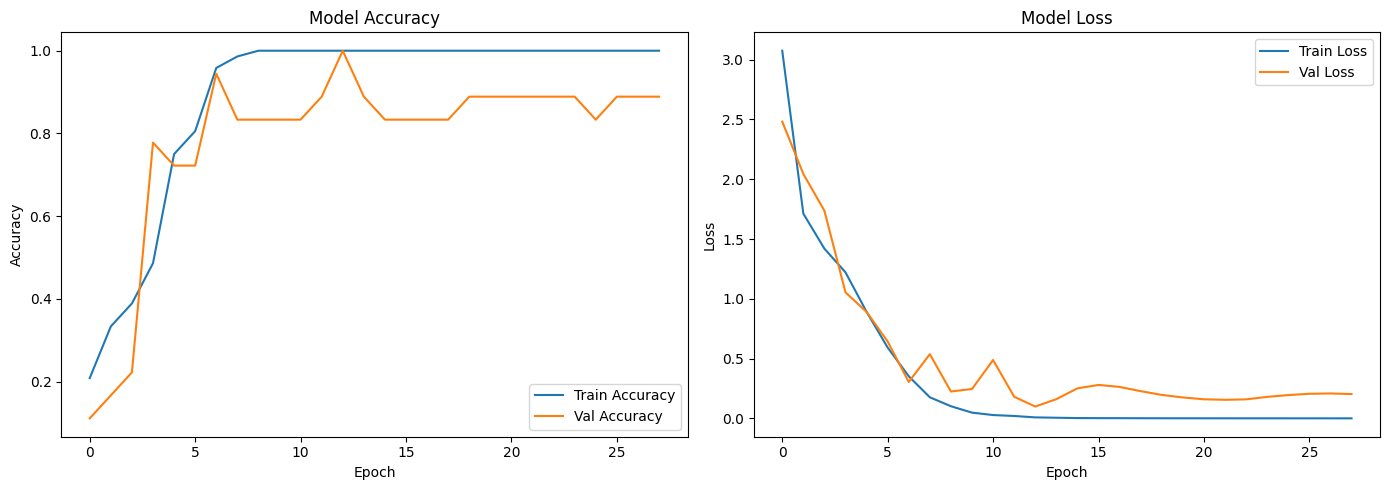

In [12]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## Task 5: Evaluate the Model

In [13]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7667 - loss: 0.4944
Test Loss:     0.4944
Test Accuracy: 0.7667


## Task 6: Save and Load the Model

In [14]:
model.save('cnn_fruits_model.h5')
print("Model saved as cnn_fruits_model.h5")

# Load and re-evaluate to confirm it saved correctly
loaded_model = keras.models.load_model('cnn_fruits_model.h5')
loss, acc = loaded_model.evaluate(test_ds)
print(f"Loaded Model - Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}")

Model saved as cnn_fruits_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7667 - loss: 0.4944
Loaded Model - Test Loss: 0.4944 | Test Accuracy: 0.7667


## Task 7: Predictions and Classification Report

In [15]:
# Collect all true labels and predictions from test set
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_dirs))

              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       0.56      1.00      0.71         5
    graviola       1.00      0.80      0.89         5
     guarana       0.71      1.00      0.83         5
     pupunha       1.00      0.60      0.75         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.77        30
   macro avg       0.84      0.77      0.76        30
weighted avg       0.84      0.77      0.76        30

